# Telecom Customer Churn Prediction

### Business Objective

The objective of this project is to develop a machine learning solution for predicting customer churn in the telecom industry.

The solution aims to:

1. Identify the key factors associated with customer churn.
2. Build and compare multiple classification models for churn prediction.
3. Generate a churn probability/risk score for each customer.
4. Create a `CHURN_FLAG` to identify customers who require retention intervention.
5. Translate model outputs into actionable customer-retention strategies.

This project follows an end-to-end machine learning workflow covering data extraction, data quality assessment, exploratory data analysis, feature engineering, preprocessing, model development, evaluation, and business deployment of predictions.

## Environment Setup and Data Source Connection

The project data is stored in a relational SQL database. In this stage, the required Python libraries are imported and a connection is established with the telecom customer database.

The database connection is used only for data extraction; subsequent data preparation and machine learning operations are performed using Python and pandas.

In [1]:
import pandas as pd
import mysql.connector
import warnings
warnings.filterwarnings('ignore')

connection = mysql.connector.connect(
    host="18.136.157.135",
    user="dm_team3",
    password="DM!$!Team!27@9!20&",
    database="project_telecom"
)

print(connection.is_connected())

True


In [2]:
query = "SELECT * FROM telecom_churn_data"

In [3]:
df = pd.read_sql(query,connection)

In [4]:
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [5]:
df.shape

(243553, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


In [7]:
df.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


In [8]:
df.isnull().sum()

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

customer_id             243553
telecom_partner              4
gender                       2
age                         57
state                       28
city                         6
pincode                 213442
date_of_registration      1220
num_dependents               5
estimated_salary        110032
calls_made                 119
sms_sent                    59
data_used                11837
churn                        2
dtype: int64

### Churn Class Distribution

The distribution of churned and retained customers is visualized to provide a clear view of the target-class composition.

This distribution will guide the selection of appropriate evaluation metrics and class-imbalance handling techniques during model development.

In [11]:
df["churn"].value_counts(normalize="True")*100

churn
0    79.952208
1    20.047792
Name: proportion, dtype: float64

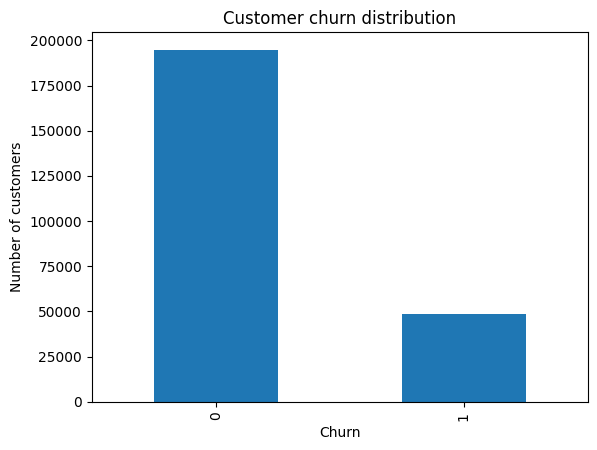

In [12]:
import matplotlib.pyplot as plt

df["churn"].value_counts().plot(kind="bar")
plt.xlabel("Churn")
plt.ylabel("Number of customers")
plt.title("Customer churn distribution")
plt.show()

## Exploratory Data Analysis — Categorical Variables

Categorical variables are identified and analyzed to understand how customer characteristics and geographic or service-related attributes are associated with churn.

In [13]:
categorical_columns = df.select_dtypes(include = "object").columns
print(categorical_columns)

Index(['telecom_partner', 'gender', 'state', 'city', 'date_of_registration'], dtype='object')


In [14]:
pd.crosstab(df["telecom_partner"],
            df["churn"], normalize="index")*100

churn,0,1
telecom_partner,,
Airtel,79.633856,20.366144
BSNL,80.139321,19.860679
Reliance Jio,79.984621,20.015379
Vodafone,80.051643,19.948357


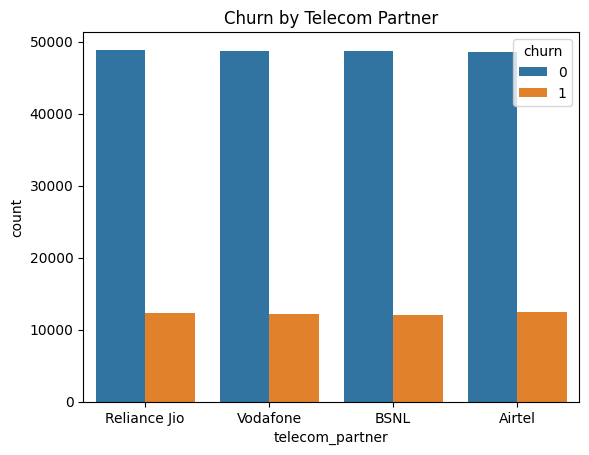

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="telecom_partner",
    hue="churn"
)

plt.title("Churn by Telecom Partner")
plt.show()

In [16]:
pd.crosstab(df["gender"], 
            df["churn"], normalize="index")*100

churn,0,1
gender,,
F,79.703001,20.296999
M,80.118786,19.881214


In [17]:
state_churn_rate = (
    df.groupby("state")["churn"]
    .mean()
    .sort_values(ascending=False)
)

state_churn_rate

state
Jharkhand            0.211194
Karnataka            0.207123
Mizoram              0.206468
Uttarakhand          0.204155
Himachal Pradesh     0.204100
Madhya Pradesh       0.203811
Assam                0.202995
Odisha               0.202479
Nagaland             0.202289
Rajasthan            0.202171
Manipur              0.201133
Telangana            0.201059
Uttar Pradesh        0.200755
Sikkim               0.200714
Haryana              0.200343
Gujarat              0.200232
Goa                  0.199563
Tamil Nadu           0.199358
Maharashtra          0.199093
Arunachal Pradesh    0.198927
Andhra Pradesh       0.198520
Meghalaya            0.197490
Bihar                0.196340
Kerala               0.195301
Tripura              0.194804
Chhattisgarh         0.194307
Punjab               0.194251
West Bengal          0.194004
Name: churn, dtype: float64

In [18]:
city_churn_rate = (
    df.groupby("city")["churn"]
    .mean()
    .sort_values(ascending=False)
)

city_churn_rate

city
Hyderabad    0.204162
Mumbai       0.201580
Kolkata      0.201569
Bangalore    0.200502
Chennai      0.197551
Delhi        0.197499
Name: churn, dtype: float64

In [19]:
numerical_cols = [
    "age",
    "num_dependents",
    "estimated_salary",
    "calls_made",
    "sms_sent",
    "data_used"
]

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,243553.0,46.077609,16.444029,18.0,32.0,46.0,60.0,74.0
num_dependents,243553.0,1.997500,1.414941,0.0,1.0,2.0,3.0,4.0
estimated_salary,243553.0,85021.137839,37508.963233,20000.0,52585.0,84990.0,117488.0,149999.0
calls_made,243553.0,49.010548,29.453556,-10.0,24.0,49.0,74.0,108.0
sms_sent,243553.0,23.945404,14.733575,-5.0,11.0,24.0,36.0,53.0
data_used,243553.0,4993.186025,2942.019547,-987.0,2490.0,4987.0,7493.0,10991.0


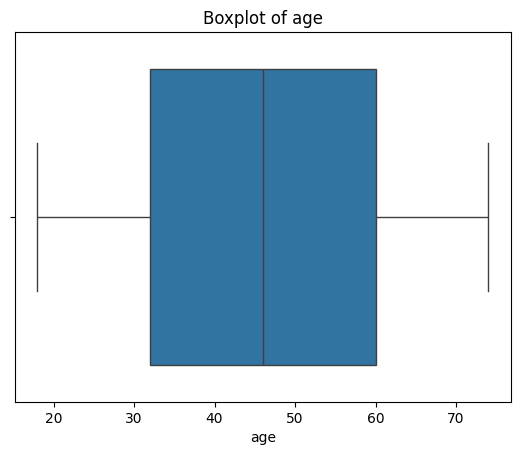

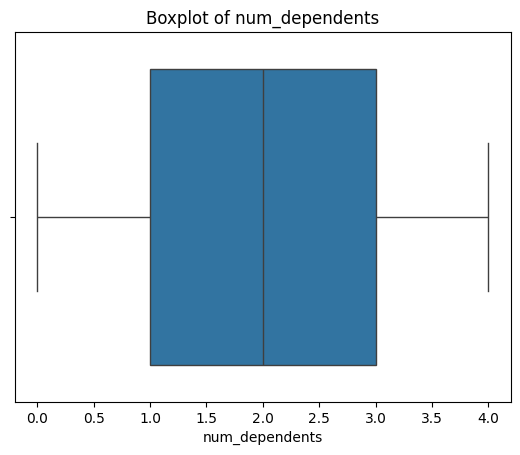

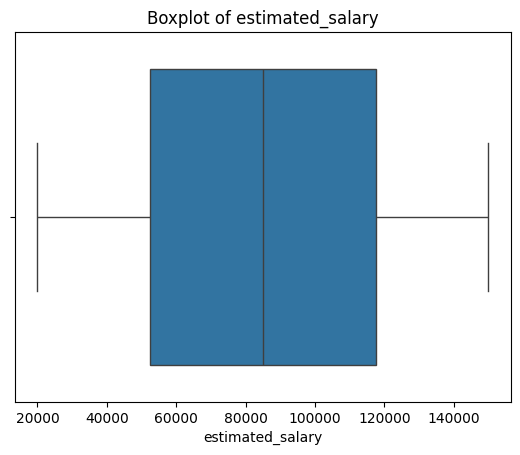

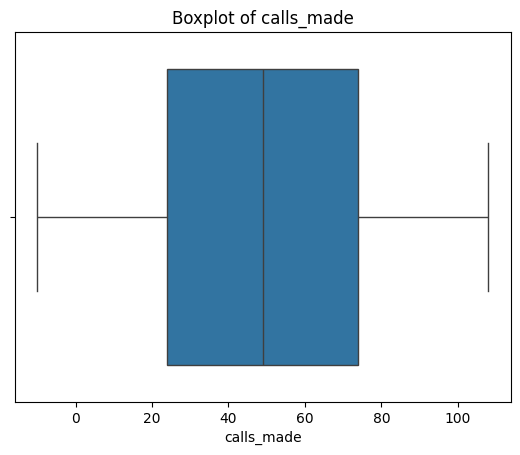

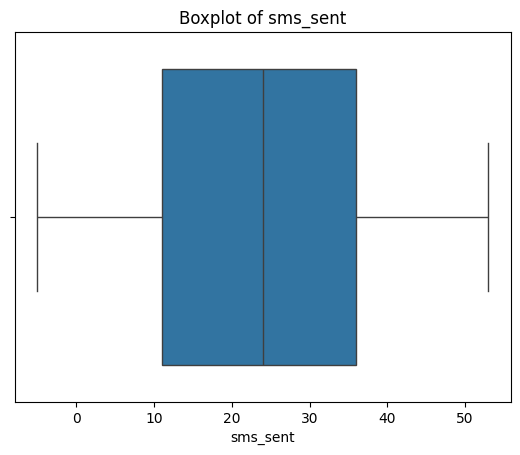

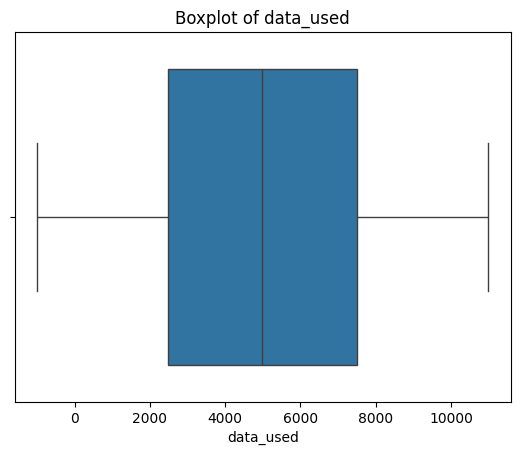

In [20]:
for col in numerical_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Feature Engineering

Feature engineering transforms raw variables into representations that are more informative for machine learning.

The registration date is converted into a datetime format and customer tenure is derived to capture the relative duration of the customer's relationship with the telecom provider.

The objective is to create business-relevant features while avoiding unnecessary information leakage.

In [21]:
df["date_of_registration"] = pd.to_datetime(df["date_of_registration"])
ref_date = df["date_of_registration"].max()
df["tenure_days"] = (ref_date - df["date_of_registration"]).dt.days

In [22]:
df.groupby("churn")["tenure_days"].mean()

churn
0    610.290875
1    608.839945
Name: tenure_days, dtype: float64

In [23]:
df_model = df.drop(columns = ["customer_id","pincode","date_of_registration"])

In [24]:
df_model

,telecom_partner,gender,age,state,city,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,tenure_days
0,Reliance Jio,F,25,Karnataka,Kolkata,4,124962,44,45,-361,0,1219
1,Reliance Jio,F,55,Mizoram,Mumbai,2,130556,62,39,5973,0,1219
2,Vodafone,F,57,Arunachal Pradesh,Delhi,0,148828,49,24,193,1,1219
3,BSNL,M,46,Tamil Nadu,Kolkata,1,38722,80,25,9377,1,1219
4,BSNL,F,26,Tripura,Delhi,2,55098,78,15,1393,0,1219
...,...,...,...,...,...,...,...,...,...,...,...,...
243548,Airtel,F,28,Mizoram,Kolkata,3,130580,28,9,4102,0,1
243549,Reliance Jio,F,52,Assam,Kolkata,0,82393,80,45,7521,0,1
243550,Reliance Jio,M,59,Tripura,Kolkata,4,51298,26,4,6547,0,1
243551,BSNL,M,49,Madhya Pradesh,Kolkata,2,83981,80,15,1125,0,1


In [25]:
x = df_model.drop("churn", axis=1)
y = df_model["churn"]

In [26]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, stratify=y)

In [27]:
categorical_features = ["telecom_partner","gender","state","city"]
numerical_features = ["age","num_dependents","estimated_salary","calls_made","sms_sent","data_used","tenure_days",]


## Feature Preprocessing Pipeline

A unified preprocessing pipeline is constructed to ensure consistent transformation of training and unseen data.

Numerical variables are standardized, while categorical variables are converted into machine-readable representations using one-hot encoding.

The preprocessing operations are encapsulated within the modeling pipeline to prevent data leakage and ensure that transformations learned from the training data are not independently fitted on the test data.

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
preprocessor = ColumnTransformer(
    transformers=[("num",StandardScaler(),numerical_features),
                  ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features) ])

## Model Evaluation Framework

A standardized evaluation function is defined to compare all candidate classification models using the same metrics.

The evaluation framework includes:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Because churn is an imbalanced classification problem, particular attention is given to recall, F1-score, and ROC-AUC rather than relying solely on accuracy.

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

result = {} 
def evaluate(name, y_test, y_pred, y_prob):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob_lr)
    result[name] = {"Accuracy": accuracy,
                    "Precision":precision,
                    "recall":recall,
                    "f1 score": f1,
                    "roc_auc_score": roc_auc}
    print(f'--- {name} ---')
    print("Accuracy:",accuracy)
    print("Precision:",precision)
    print("Recall:",recall)
    print("F1:",f1)
    print("ROC-AUC:",roc_auc)
    return y_prob

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(steps=[("preprocessor", preprocessor),
                                 ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
logistic_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['telecom_partner','gender','age',...,'sms_sent','data_used','tenure_days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [31]:
y_pred_lr = logistic_model.predict(x_test)
y_prob_lr = logistic_model.predict_proba(x_test)[:, 1]
evaluate("logistic regression", y_test, y_pred_lr, y_prob_lr)

--- logistic regression ---
Accuracy: 0.5108497054053499
Precision: 0.20465428883474754
Recall: 0.4989247311827957
F1: 0.29025051383634687
ROC-AUC: 0.5031772063299589


array([0.48448228, 0.49676728, 0.51967157, ..., 0.50532457, 0.49175414,
       0.4872096 ], shape=(48711,))

In [32]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline(steps=[("preprocessor", preprocessor),
                    ("model", DecisionTreeClassifier(random_state=42, class_weight="balanced"))])
dt_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['telecom_partner','gender','age',...,'sms_sent','data_used','tenure_days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [33]:
y_pred_dt = dt_model.predict(x_test)
y_prob_dt = dt_model.predict_proba(x_test)[:,1]
evaluate("decesion tree", y_test, y_pred_dt, y_prob_dt)

--- decesion tree ---
Accuracy: 0.6709162201556117
Precision: 0.20282705625652214
Recall: 0.21894521249359958
F1: 0.21057815424012608
ROC-AUC: 0.5031772063299589


array([0., 0., 1., ..., 0., 0., 0.], shape=(48711,))

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[("preprocessor", preprocessor),
                    ("model", RandomForestClassifier(n_estimators=50,random_state=42,n_jobs=-1,class_weight="balanced"))])
rf_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['telecom_partner','gender','age',...,'sms_sent','data_used','tenure_days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [35]:
y_pred_rf = rf_model.predict(x_test)
y_prob_rf = rf_model.predict_proba(x_test)[:,1]
evaluate("Random forest", y_test, y_pred_rf, y_prob_rf)

--- Random forest ---
Accuracy: 0.7891646650653856
Precision: 0.20809248554913296
Recall: 0.018433179723502304
F1: 0.03386641580432737
ROC-AUC: 0.5031772063299589


array([0.18, 0.32, 0.4 , ..., 0.3 , 0.34, 0.36], shape=(48711,))

In [38]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

scaled_pos = (y_train==0).sum()/(y_train==1).sum()
xg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scaled_pos,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])
xg_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['telecom_partner','gender','age',...,'sms_sent','data_used','tenure_days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [39]:
y_pred_xg = xg_model.predict(x_test)
y_prob_xg = xg_model.predict_proba(x_test)[:,1]
evaluate("XGBoost", y_test, y_pred_xg, y_prob_xg)

--- XGBoost ---
Accuracy: 0.5122662232349983
Precision: 0.20068449197860963
Recall: 0.48038914490527396
F1: 0.2831019915509958
ROC-AUC: 0.5031772063299589


array([0.4953141 , 0.4994803 , 0.51426435, ..., 0.53710747, 0.51583296,
       0.46171036], shape=(48711,), dtype=float32)

## Model Performance Comparison

The performance of all candidate models is consolidated into a single comparison table.

Model selection should consider the business objective rather than optimizing a single metric. In a churn-retention use case, the ability to identify actual churners is particularly important, making recall, F1-score, and ROC-AUC important decision criteria alongside accuracy.

In [49]:
comparison = pd.DataFrame.from_dict(result, orient='index')
comparison.sort_values("Accuracy")
comparison.round(4)

,Accuracy,Precision,recall,f1 score,roc_auc_score
logistic regression,0.5108,0.2047,0.4989,0.2903,0.5032
decesion tree,0.6709,0.2028,0.2189,0.2106,0.5032
Random forest,0.7892,0.2081,0.0184,0.0339,0.5032
XGBoost,0.5123,0.2007,0.4804,0.2831,0.5032


## Final Model Selection

The final model is selected based on the project's business objective and the comparative evaluation results.

The selected model is then used to generate customer-level churn probabilities. Model selection is based on predictive performance on the held-out test set and not on training performance.

In [58]:
best_name = max(result, key=lambda k: result[k]["Accuracy"])
print(f"\nUsing {best_name} (Accuracy={result[best_name]['Accuracy']:.4f}) for scoring.")


Using Random forest (Accuracy=0.7892) for scoring.


In [60]:
best_pipe = xg_model

## Customer-Level Churn Risk Scoring

The selected model is used to estimate the probability that each customer will churn.

Unlike a binary prediction alone, the probability score provides a continuous measure of customer risk and enables the business to prioritize customers according to their likelihood of churn.

In [61]:
df["churn_probability"] = best_pipe.predict_proba(x)[:, 1]

## CHURN_FLAG and Risk Segmentation

A binary `CHURN_FLAG` is derived from the predicted churn probability.

Customers exceeding the selected probability threshold are classified as potential churners.

Customers are also segmented into Low, Medium, and High risk tiers to support differentiated retention strategies.

The probability threshold should ultimately be selected according to the business cost of missed churners versus unnecessary retention interventions.

In [62]:
df["CHURN_FLAG"] = (df["churn_probability"] >= 0.5).astype(int)
df["risk_tier"] = pd.cut(df["churn_probability"], bins=[0, 0.33, 0.66, 1.0],labels=["Low", "Medium", "High"], include_lowest=True)

In [65]:
df[["customer_id", "telecom_partner", "state", "city", "churn",
    "churn_probability", "CHURN_FLAG", "risk_tier"]].to_csv("churn_detection", index=False)
print(f"\nScored file written to {'churn_detection'}")


Scored file written to churn_detection


## Final Scored Customer Dataset

The exported scoring dataset is reloaded and inspected to verify the final structure and confirm that the customer-level predictions and risk classifications have been generated successfully.

In [67]:
churn_detection = pd.read_csv("churn_detection")
churn_detection 

,customer_id,telecom_partner,state,city,churn,churn_probability,CHURN_FLAG,risk_tier
0,1,Reliance Jio,Karnataka,Kolkata,0,0.467991,0,Medium
1,2,Reliance Jio,Mizoram,Mumbai,0,0.515949,1,Medium
2,3,Vodafone,Arunachal Pradesh,Delhi,1,0.488728,0,Medium
3,4,BSNL,Tamil Nadu,Kolkata,1,0.534125,1,Medium
4,5,BSNL,Tripura,Delhi,0,0.464613,0,Medium
...,...,...,...,...,...,...,...,...
243548,243549,Airtel,Mizoram,Kolkata,0,0.507181,1,Medium
243549,243550,Reliance Jio,Assam,Kolkata,0,0.478530,0,Medium
243550,243551,Reliance Jio,Tripura,Kolkata,0,0.515200,1,Medium
243551,243552,BSNL,Madhya Pradesh,Kolkata,0,0.488793,0,Medium


# Business Insights and Recommendations

## Key Business Objective

The purpose of the churn prediction system is not only to classify customers but to enable proactive retention.

Customers identified with high predicted churn probability can be prioritized for retention campaigns before they migrate to competitors.

## Recommended Retention Strategy

### High-Risk Customers
- Prioritize for immediate customer-care intervention.
- Provide personalized retention offers.
- Review unresolved service issues.
- Consider targeted discounts or plan upgrades.

### Medium-Risk Customers
- Monitor customer engagement and usage patterns.
- Provide targeted promotional offers.
- Include customers in proactive retention campaigns.

### Low-Risk Customers
- Continue standard customer engagement.
- Encourage loyalty through existing programs.
- Monitor for changes in future behavior.

## Model Deployment Perspective

The trained model can be integrated into a recurring customer-scoring pipeline. New customer data can be passed through the same preprocessing and prediction pipeline to generate updated churn probabilities and risk tiers.

The business can then use these scores to prioritize customer-retention activities.

## Conclusion

This project demonstrates an end-to-end machine learning workflow for telecom customer churn prediction, from data extraction and exploratory analysis through model development, evaluation, risk scoring, and business-oriented customer segmentation.